In [ ]:
# EXPERIMENT: Genuine nonlinear drift versus Euler's numerical drift
#
# Goal:
# Determine whether a trajectory near the Hopf equilibrium moves outward
# after one full revolution, and distinguish that motion from numerical error.
#
# 1. THE SYSTEM
# For the Izhikevich model with a = 0.02 and b = 0.2, the Hopf point is
# I_H = 3.7975, at equilibrium (v*, u*) = (-62.25, -12.45).
#
# Shift the equilibrium to the origin:
#     x = v + 62.25
#     y = u + 12.45
# Then change coordinates:
#     X = x
#     Y = (y - 0.02*x) / 0.06
#
# At I = I_H, the smooth differential equations become:
#     dX/dt = -0.06*Y + 0.04*X**2
#     dY/dt =  0.06*X - (0.04/3)*X**2
#
# We study local motion near the equilibrium, without applying a spike reset.
# The linear part is pure rotation with angular speed omega = 0.06.
# Its period is 2*pi/omega ≈ 104.72, and its trajectories are circles
# in the (X, Y) coordinates. The nonlinear terms distort this motion.
#
# 2. WHY AN OUTWARD SPIRAL ALONE IS NOT ENOUGH
# First we tested the linear oscillator:
#     dX/dt = -omega*Y
#     dY/dt =  omega*X
# Its exact radius is constant, but forward Euler creates outward drift.
#
# Each Euler step multiplies the radius by sqrt(1 + (h*omega)**2).
# After N = T/h steps:
#     log(r_final/r_initial) = (N/2)*log(1 + (h*omega)**2)
#                           ≈ T*h*omega**2 / 2
#
# Thus Euler produces artificial growth that vanishes as h -> 0.
# When comparing step sizes, keep the physical duration T fixed:
# halving h requires twice as many steps.
#
# Euler implementation:
# Compute BOTH derivatives from the old X, Y before updating either variable.
# Recompute the derivatives on every iteration.
#
# 3. MEASURING ONE COMPLETE TURN
# For the nonlinear experiment, start at (X, Y) = (0.1, 0), so r0 = 0.1.
# Plot Y against X, using equal axis scaling to avoid visual distortion.
#
# The radius fluctuates within a turn, so measure it at the same angular
# position on successive turns rather than at an arbitrary stopping time.
# The nonlinear period need not equal the linear period 2*pi/omega.
#
# Starting on the positive X-axis, the trajectory initially moves upward.
# Detect its first return to that axis from below using consecutive points:
#     Y[i] < 0 <= Y[i+1], with X[i+1] > 0
#
# Search only through len(Y)-1 indices because we access i+1.
# Stop after the FIRST return crossing.
#
# 4. INTERPOLATING THE CROSSING
# A step usually overshoots Y = 0. Approximate the crossing by interpolating
# along the segment between the points before and after it:
#     alpha = -Y[i] / (Y[i+1] - Y[i])
#     X_cross = X[i] + alpha*(X[i+1] - X[i])
#
# Sanity checks:
#     0 <= alpha <= 1
#     X_cross lies between X[i] and X[i+1]
#
# At the positive X-axis, the radius equals X_cross. Therefore:
#     displacement = X_cross - r0
#
# Positive displacement means net outward motion after one revolution.
# This interpolation estimates the crossing; it does not remove Euler error.
#
# 5. STEP-SIZE STUDY: RESULTS FOR r0 = 0.1
#     h          displacement
#     0.1000     0.0021549474
#     0.0500     0.0011892030
#     0.0250     0.0007097998
#     0.0125     0.0004709438
#
# These positive values decrease as h decreases. Decreasing values alone
# do NOT establish whether the limiting displacement is zero or positive.
#
# 6. RICHARDSON EXTRAPOLATION
# Let D be the true one-turn displacement and D_h the numerical estimate.
# In the small-step regime, assume Euler's error has the expansion:
#     D_h = D + C*h + O(h**2)
# Then:
#     D_(h/2) = D + C*h/2 + O(h**2)
#
# Cancel the leading error:
#     D_extrapolated = 2*D_(h/2) - D_h = D + O(h**2)
#
# Successive pairs above give:
#     0.0002234585
#     0.0002303967
#     0.0002320877
#
# These estimates settle near a positive displacement of 0.000232.
#
# General rule for leading error proportional to h**p:
#     D_extrapolated = (2**p * D_(h/2) - D_h) / (2**p - 1)
#
# For p = 2, halving h quarters the leading error, so:
#     D_extrapolated = (4*D_(h/2) - D_h) / 3
#
# Extrapolation relies on the error expansion being valid. Check several
# successive step sizes; one extrapolated value is not a guarantee.
#
# 7. CONNECTION TO THE HOPF ANALYSIS
# Our analytical calculation predicts, for small initial radius r0:
#     D = [pi*(0.04)**2 / (6*(0.06)**2)] * r0**3 + O(r0**4)
#
# At r0 = 0.1, the leading term is approximately 0.0002327106,
# close to the extrapolated numerical displacement.
# Exact agreement is not expected because both higher-order nonlinear
# terms and residual numerical error remain.
#
# The positive cubic drift supports our subcritical Hopf calculation:
# at the threshold, weak nonlinear outward motion remains even though
# the linearized system has no radial growth.
#
# Scope:
# This experiment provides numerical evidence at a finite initial radius.
# It does not by itself prove the Hopf type or determine global firing
# behavior, which also depends on the dynamics farther away and the reset.
#
# NEXT CHECK (not yet performed):
# Repeat with smaller r0. The leading cubic prediction implies that
# halving r0 reduces the true one-turn displacement by approximately 8.
# Refine h sufficiently: the smaller nonlinear signal is easier for
# numerical error to overwhelm.





import numpy as np
import matplotlib.pyplot as plt




def Euler(h):
    X = 1.0
    Y = 0.0
    omega = 0.06
    T = 1000
    n_steps = int(round(T / h))

    for _ in range(n_steps):
        dX = -omega * Y
        dY = omega * X

        X = X + h * dX
        Y = Y + h * dY

    r = np.sqrt(X**2 + Y**2)
    log_r = np.log(r)
    predicted_log_r = (n_steps / 2) * np.log1p((h * omega)**2)
    return h, log_r, predicted_log_r, r - 1
   

for h in [0.1, 0.05, 0.025]:
    print(Euler(h))



        

    





(0.1, np.float64(0.17999676007775772), np.float64(0.17999676007775792), np.float64(0.1972134842369302))
(0.05, np.float64(0.08999959500243138), np.float64(0.08999959500242997), np.float64(0.09417384056737554))
(0.025, np.float64(0.04499994937505851), np.float64(0.04499994937507594), np.float64(0.04602780695361908))


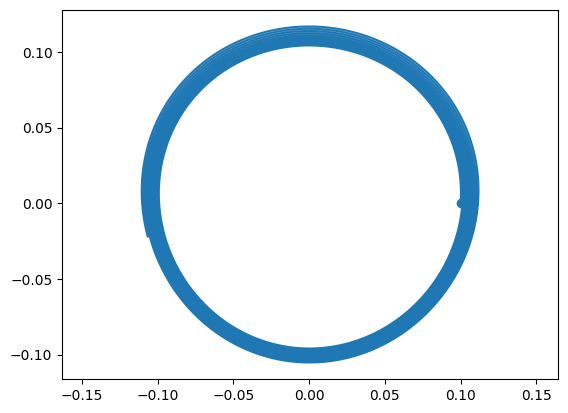

In [ ]:
def hopf(X,Y,h): 
    X_values = []
    Y_values = []
    T = 1000
    n_steps = int(np.round(T/h))
    for _ in range(n_steps):
        X_values.append(X)
        Y_values.append(Y)
        dX = -0.06 * Y + 0.04*X**2
        dY = 0.06 * X - 0.04/3 *X**2 
        X = X + h * dX
        Y = Y + h * dY
        
    return X_values, Y_values


for h in [0.05]: 
    Xs, Ys = hopf(0.1,0,h)
    plt.plot(Xs,Ys)
    plt.axis("equal")

plt.scatter(0.1,0)

    

In [41]:
h_values = [0.025,0.0125,0.00625,0.003125]
displacement = []
for h in h_values:
    X, Y = hopf(0.05,0,h)
    for i in range(len(Y) - 1): 
        if Y[i] < 0 and Y[i + 1] >= 0 and X[i + 1] > 0: 
            print(i, X[i], Y[i], X[i + 1], Y[i + 1])
            X_c = X[i] + (Y[i] *(X[i + 1] - X[i])/(Y[i] - Y[i + 1]))
            displacement.append(X_c - 0.05)
            break 
for j in range(len(h_values) - 1):
    #Richardson_Extrapolation
    extrapolated_displacement = 2 * displacement[j + 1] - displacement[j]
    print(extrapolated_displacement)
            


        



4189 0.05026430050409095 -5.5473732236928917e-05 0.050266910214594465 1.9080551884152324e-05
8379 0.05014684482571261 -1.9122602222226986e-05 0.050148116520687264 1.8068413722728457e-05
16759 0.050088196741304894 -1.052837611064048e-06 0.050088824342982195 1.752116721252565e-05
33518 0.05005857917120108 -1.32591055591735e-06 0.05005889265247789 7.95566214915621e-06
2.8755077109275662e-05
2.896593534112285e-05
2.901559066543352e-05
